<a href="https://colab.research.google.com/github/anshulkr69/learning-to-make-machine-learn/blob/main/13-Classification_Metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Accuracy

**$\text{Accuracy} = \frac{\text{Correct Predictions}}{\text{Total Predictions}}$**


In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, multilabel_confusion_matrix, ConfusionMatrixDisplay

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/iris.csv')

In [3]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
X, y = df.drop('species', axis=1), df.species

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

In [7]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)

y_test = le.transform(y_test)

In [8]:
le.classes_

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [9]:
y_test

array([0, 1, 1, 0, 2, 1, 2, 0, 0, 2, 1, 0, 2, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       1, 0, 2, 1, 0, 0, 1, 2])

In [10]:
lr = LogisticRegression()
clf = DecisionTreeClassifier()


In [11]:
lr.fit(X_train, y_train)
clf.fit(X_train, y_train)
y_pred1 = lr.predict(X_test)
y_pred2 = clf.predict(X_test)

In [12]:
print("LR:",accuracy_score(y_test, y_pred1))
print("DT:",accuracy_score(y_test, y_pred2))

LR: 0.9666666666666667
DT: 0.9666666666666667


In [13]:
compare = pd.DataFrame({'target':y_test,'prediction_lr':y_pred1,'prediction_clf':y_pred2})

In [14]:
compare

,target,prediction_lr,prediction_clf
0,0,0,0
1,1,1,1
2,1,1,1
3,0,0,0
4,2,2,2
5,1,1,1
6,2,2,2
7,0,0,0
8,0,0,0
9,2,2,2


In [15]:
import matplotlib.pyplot as plt


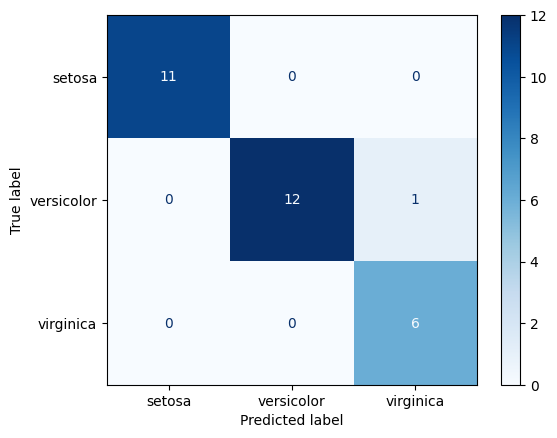

In [16]:
# 1. Calculate the confusion matrix from actual and predicted values
cm = confusion_matrix(y_test, y_pred2)

# 2. Initialize the display with the matrix and your class labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['setosa', 'versicolor', 'virginica'])

# 3. Plot the confusion matrix (e.g., using a blue color map)
disp.plot(cmap=plt.cm.Blues)

# 4. Display the plot
plt.show()

### Where accuracy fails!!
**IMBALANCED DATA**:
Let's say we are making a model to detect terrorists at an Airport through video footage. The data has 999 non terrorists and 1 terrorist. If the model makes a prediction that there are no terrorists, the accuracy will still be 99.9%. Number wise it is great but in reality this is a very very bad prediction model. This is the problem in accuracy, it fails to tell the full story.

### The problem with accuracy that **CONFUSION MATRIX** solves:

There is no way in which the accuracy can tell what is wrong. Whether False Positives are more frequent of False Negatives. This is what a confusion matrix solves.

$ $

**Key Terms** *(Only for binary classifications)*:

1. Type 1 Error: False Positives
2. Type 2 Error: False Negatives

# Confusion Matrix (For binary classify-able ones):
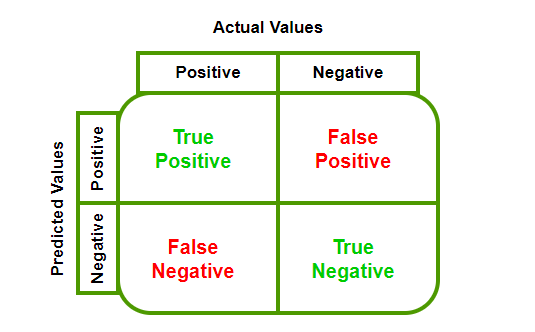

New Accuracy formula according to this table:

$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$


## Key Terms related to CM:

### **Precision:**
$\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}$


It tells us what proportion of predicted positives are truly positives. A good metric to lookout for when False Positive is a sensitive thing. `Eg. Spam mail classifier where Spam is positive`

### **Recall:**
$\text{Recall} = \frac{TP}{TP + FN}$

It tells us what proportion of actual positives is rightly classified. A key metric to keep an eye on when False Negative is a sensitive thing. `Eg. Cancer Detection where Cancer is positive.`

### **IMPORTANT POINTS TO KEEP IN MIND:**

1. If type 1 errors are more disruptive we want our precision to be better.
2. If type 2 errors are more dangerous we want our recall to be better.



```
What if we can't have a say on which error is more dangerous??
```

This is where ***F1 SCORE*** comes in!!



### **F1 Score**:
Its a metric that uses both recall and precision to penalize the model with the score that is lesser of the two.

### **$F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$

$ $

It's basically the formula for Harmonic mean of Precision and Recall and hence it tends to favour the smaller value.

$ $

If it were to be an Arithmetic mean, it would have given a value exactly in the middle of the two and also it is equally influenced by both values. This means there is no penalty even if Penalty is zero and Recall is 100, which is very wrong.

Whereas H.M.≤ A.M. (Basic Formula) ⇒ H.M. is in favour of smaller value.

Everything we did above was for binary classifiers.

For Multi-Class data, we calculate these metrics for each class and then calculate the final score in two ways:
1. macro: Its just the mean of the specific metric of every class. (Suitable for evenly classified data)
2. weighted: It's the weighted mean i.e. summation of the metric of each class multiplied by the weight(count of the class/total count of all classes) of itself, whole divided by no. of classes.

In [26]:
from sklearn.metrics import recall_score, f1_score, precision_score
f1_score(y_test, y_pred1, average= 'weighted')  # or we can change the average method to macro

0.9672820512820512

In [25]:
# There is a function called classification report which does all of this for us

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      0.92      0.96        13
           2       0.86      1.00      0.92         6

    accuracy                           0.97        30
   macro avg       0.95      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30



support is the count of data lying in that class